# Laboratorio 1 — Series de Tiempo
## Parte 1: Análisis Exploratorio de Datos (EDA)

**CC3084 — Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

**Dataset:** ingreso de viajeros internacionales a Guatemala, enero 2009 – junio 2026 (formato largo, 161,036 registros).




## 0. Configuración y carga

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL
from pathlib import Path

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

FIG = Path('figuras'); FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
    'axes.spines.top': False, 'axes.spines.right': False,
})
AZUL, NARANJA, VERDE, ROJO, GRIS = '#1f4e79', '#e07b39', '#2e8b57', '#c0392b', '#7f8c8d'

def guardar(nombre):
    plt.savefig(FIG / f'{nombre}.png')

def miles(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1000:,.0f}'))

In [2]:
RUTA = 'Base_Migracion_2009-2026jun.xlsx'

df = pd.read_excel(RUTA, sheet_name='Datos')
print(f'Registros: {df.shape[0]:,}   Columnas: {df.shape[1]}')
df.head()

Registros: 161,036   Columnas: 13


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


### Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `Año`, `Mes cod`, `Mes` | temporal | Año, número de mes (1–12) y nombre abreviado |
| `Vía` | categórica | Aérea, Terrestre, Marítima |
| `Frontera` | categórica | Puesto fronterizo de ingreso (22 categorías) |
| `País` | categórica | País de residencia (hasta 2022); agrupación de mercado (desde 2023) |
| `Región`, `Región dos`, `Regiones OMT`, `MCEO` | categórica | Cuatro jerarquías geográficas/comerciales distintas |
| `Agrupación Residencia` | categórica | Región de residencia |
| `Tipo de Viajero` | categórica | Turista, Excursionista, Viajero, Crucerista |
| `Viajero` | numérica | **Medida**: cantidad de viajeros de la combinación |

El archivo está en **formato largo**: cada fila es una combinación
(mes × vía × frontera × país × tipo) y `Viajero` es la medida. No hay filas de total,
por lo que sumar es seguro y no hay doble conteo.

In [3]:
df.info()
print()
print(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  object 
 3   Vía                    161036 non-null  object 
 4   Frontera               161036 non-null  object 
 5   País                   161036 non-null  object 
 6   Región                 161036 non-null  object 
 7   Región dos             161036 non-null  object 
 8   Regiones OMT           161036 non-null  object 
 9   MCEO                   161036 non-null  object 
 10  Agrupación Residencia  161036 non-null  object 
 11  Tipo de Viajero        161036 non-null  object 
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), object(10)
memory usage: 16.0+ MB

                          cou

## 1. Calidad de datos

Antes de construir series revisamos: valores faltantes, duplicados, categorías inconsistentes
y coherencia de la medida. Este bloque corresponde al inciso **1.e** del enunciado.

### 1.1 Valores faltantes

In [4]:
faltantes = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct': (df.isna().mean() * 100).round(2),
    'vacios_texto': [(df[c].astype(str).str.strip() == '').sum() for c in df.columns],
})
print(faltantes)
print('\nTotal de celdas nulas:', df.isna().sum().sum())

                       nulos  pct  vacios_texto
Año                        0  0.0             0
Mes cod                    0  0.0             0
Mes                        0  0.0             0
Vía                        0  0.0             0
Frontera                   0  0.0             0
País                       0  0.0             0
Región                     0  0.0             0
Región dos                 0  0.0             0
Regiones OMT               0  0.0             0
MCEO                       0  0.0             0
Agrupación Residencia      0  0.0             0
Tipo de Viajero            0  0.0             0
Viajero                    0  0.0             0

Total de celdas nulas: 0


**Interpretación.** No existen valores nulos ni cadenas vacías en ninguna de las 13 columnas.
Sin embargo, la ausencia de `NaN` no significa ausencia de faltantes: más abajo encontramos
faltantes *codificados como texto* (`'0'`, `'0x2a'`), que es un patrón típico cuando los datos
vienen de una exportación de sistema. Estos son los que realmente hay que tratar.

### 1.2 Duplicados

In [5]:
llave = ['Año', 'Mes cod', 'Vía', 'Frontera', 'País', 'Tipo de Viajero']

print('Filas idénticas en todas las columnas:', df.duplicated().sum())
print('Filas repetidas según la llave lógica :', df.duplicated(subset=llave).sum())

rep = df[df.duplicated(subset=llave, keep=False)].sort_values(llave)
print('\nRegistros involucrados:', len(rep), '| años afectados:', sorted(rep['Año'].unique()))
rep[llave + ['Agrupación Residencia', 'Viajero']].head(8)

Filas idénticas en todas las columnas: 0
Filas repetidas según la llave lógica : 22

Registros involucrados: 42 | años afectados: [2020, 2021, 2022]


,Año,Mes cod,Vía,Frontera,País,Tipo de Viajero,Agrupación Residencia,Viajero
130128,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,3.0
130129,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Resto del Mundo,1.0
131981,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,44.0
131982,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,Resto del Mundo,223.0
132717,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,4.0
132718,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Resto del Mundo,1.0
133281,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,Estados Unidos de América,7.0
133282,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,México,13.0


**Interpretación.** No hay duplicados exactos. Las 22 filas que se repiten según la llave lógica
**no son duplicados reales**: difieren en `Agrupación Residencia`, una columna que quedó etiquetada
de forma inconsistente en el tramo 2020–2022 (p. ej. España aparece a la vez como *España*,
*Otros Europa* y *Resto de mundo*). Eliminarlas restaría viajeros que sí existen.

**Decisión:** no se eliminan. Como todas las series se construyen **agregando con `groupby` + `sum`**,
estas filas se consolidan solas y el total se conserva exacto. Sí descartamos
`Agrupación Residencia` como variable de análisis por ser poco confiable.

### 1.3 Consistencia de las categorías

In [6]:
for col in ['Vía', 'Tipo de Viajero', 'Región dos']:
    print(f'--- {col} ({df[col].nunique()} categorías) ---')
    print(df[col].value_counts().to_string(), '\n')

print('--- Etiquetas problemáticas ---')
raras = df[(df['Región dos'].isin(['0', 'Cruceros'])) | (df['Regiones OMT'] == '0x2a')]
print(raras[['Año', 'País', 'Región dos', 'Regiones OMT', 'Tipo de Viajero', 'Viajero']].head(10).to_string())
print('\nFilas afectadas:', len(raras), '| viajeros:', f"{raras['Viajero'].sum():,.0f}",
      f"({raras['Viajero'].sum()/df['Viajero'].sum()*100:.2f}% del total)")

--- Vía (3 categorías) ---
Vía
Terrestre    125873
Aérea         24999
Marítima      10164 

--- Tipo de Viajero (4 categorías) ---
Tipo de Viajero
Turista          117912
Viajero           23190
Excursionista     19730
Cruceristas         204 

--- Región dos (11 categorías) ---
Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      196
0                                 13
Cruceros                           8 

--- Etiquetas problemáticas ---
         Año                             País Región dos Regiones OMT Tipo de Viajero  Viajero
136757  2022        Islas Vírgenes Americanas          0    EL CARIBE         Turista     43.0
136795  2022                         Cruceros   Cruceros     Cruceros     Cru

**Interpretación.** Tres problemas de etiquetado, todos concentrados en 2022:

1. `Región dos = '0'` y `Regiones OMT = '0x2a'` → faltantes codificados como texto (Islas Vírgenes
   Americanas, R. D. del Congo).
2. `Región dos = 'Cruceros'` y `'Cruceristas'` → una **vía de transporte** metida dentro de una
   variable **geográfica**: rompe la jerarquía de la variable.
3. `Tipo de Viajero = 'Cruceristas'` existe solo hasta 2022; desde 2023 los cruceros se miden por
   fuente portuaria externa y ya no aparecen.

El impacto en volumen es marginal (0.05 %), pero contamina los rankings por región, así que se corrige.

### 1.4 La medida `Viajero`

count    161036.00
mean        324.70
std        2387.75
min           0.00
25%           2.00
50%           7.00
75%          38.89
max       92336.04

Negativos: 0 | Ceros: 54 | Con decimales: 51272
Total de viajeros en el período: 52,287,937


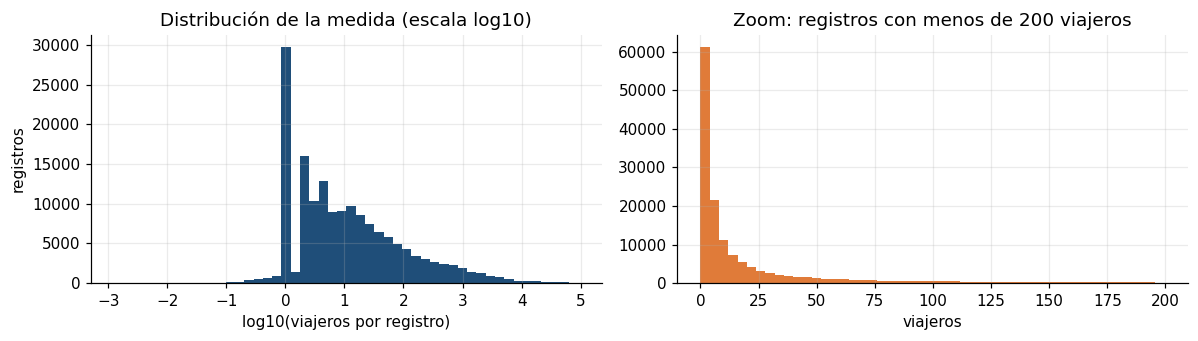

In [7]:
v = df['Viajero']
print(v.describe().round(2).to_string())
print('\nNegativos:', (v < 0).sum(), '| Ceros:', (v == 0).sum(),
      '| Con decimales:', (v % 1 != 0).sum())
print('Total de viajeros en el período:', f'{v.sum():,.0f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(np.log10(v[v > 0]), bins=50, color=AZUL)
ax[0].set(title='Distribución de la medida (escala log10)', xlabel='log10(viajeros por registro)', ylabel='registros')
ax[1].hist(v[v < 200], bins=50, color=NARANJA)
ax[1].set(title='Zoom: registros con menos de 200 viajeros', xlabel='viajeros')
plt.tight_layout(); guardar('01_medida'); plt.show()

**Interpretación.** La medida no tiene negativos y solo 54 ceros. Es **fuertemente asimétrica a la
derecha**: la mediana es de apenas 7 viajeros por registro frente a una media de ~325 y un máximo
de ~92,000. Esto es esperable en formato largo — miles de combinaciones país×frontera con volumen
mínimo conviven con unas pocas de volumen masivo (Valle Nuevo–El Salvador, La Aurora–EE. UU.).

Hay valores **con decimales**: son estimaciones expandidas de encuesta, no conteos exactos. No se
redondean a nivel de registro porque el error se acumularía; se dejan y se redondea únicamente al
final, cuando ya están agregados en la serie mensual.

> **Ojo:** esta asimetría es una propiedad del formato largo, **no** de la serie de tiempo. Los
> valores atípicos relevantes para el laboratorio se buscan sobre la serie mensual agregada
> (sección 6), no sobre los registros individuales.

## 2. Limpieza y variable temporal

Aplicamos las correcciones detectadas y creamos la columna `fecha` (primer día del mes), que es
el índice natural de todas las series.

In [8]:
d = df.copy()

# 1) Fecha mensual
d['fecha'] = pd.to_datetime(dict(year=d['Año'], month=d['Mes cod'], day=1))

# 2) Faltantes codificados como texto -> etiqueta explícita
d['Región dos']   = d['Región dos'].replace({'0': 'Sin especificar'})
d['Regiones OMT'] = d['Regiones OMT'].replace({'0x2a': 'SIN ESPECIFICAR'})

# 3) 'Cruceros'/'Cruceristas' no son regiones geográficas
d['Región dos'] = d['Región dos'].replace({'Cruceros': 'Sin especificar', 'Cruceristas': 'Sin especificar'})

# 4) Normalización de espacios en las categóricas
for col in d.select_dtypes(include='object').columns:
    d[col] = d[col].astype(str).str.strip()

print('Cobertura temporal:', d['fecha'].min().date(), '->', d['fecha'].max().date())
print('Meses distintos:', d['fecha'].nunique(), '(esperados: 210)')

# Verificación de que no falta ningún mes
esperados = pd.date_range(d['fecha'].min(), d['fecha'].max(), freq='MS')
print('Meses sin datos:', len(set(esperados) - set(d['fecha'].unique())))

Cobertura temporal: 2009-01-01 -> 2026-06-01
Meses distintos: 210 (esperados: 210)
Meses sin datos: 0


**Verificación clave:** los 210 meses entre enero 2009 y junio 2026 están presentes, sin huecos.
Esto es lo que permite tratar los datos como una serie de frecuencia mensual regular sin imputar.

## 3. Comportamiento temporal (inciso 1.a)

### 3.1 La advertencia metodológica más importante del dataset

El enunciado y las notas del archivo avisan de un quiebre entre 2022 y 2023: la categoría
`Viajero` (comercio fronterizo, tránsito, tripulación) deja de contabilizarse igual. Vale la pena
**verificarlo con los datos** antes de decidir sobre qué serie se va a modelar.

Tipo de Viajero  Cruceristas  Excursionista  Turista  Viajero  TOTAL  TUR+EXC
Año                                                                          
2009                    0.08           0.26     1.62     0.07   2.03     1.88
2010                    0.07           0.30     1.70     0.08   2.15     2.00
2011                    0.07           0.32     1.76     0.08   2.23     2.08
2012                    0.07           0.36     1.78     0.09   2.30     2.14
2013                    0.07           0.38     1.91     0.07   2.43     2.29
2014                    0.07           0.45     2.21     0.03   2.76     2.66
2015                    0.08           0.51     2.41     0.05   3.04     2.92
2016                    0.10           0.36     2.64     0.40   3.50     3.00
2017                    0.13           0.58     2.72     0.48   3.92     3.31
2018                    0.15           0.78     3.01     0.31   4.26     3.79
2019                    0.13           1.08     3.05     0.43   

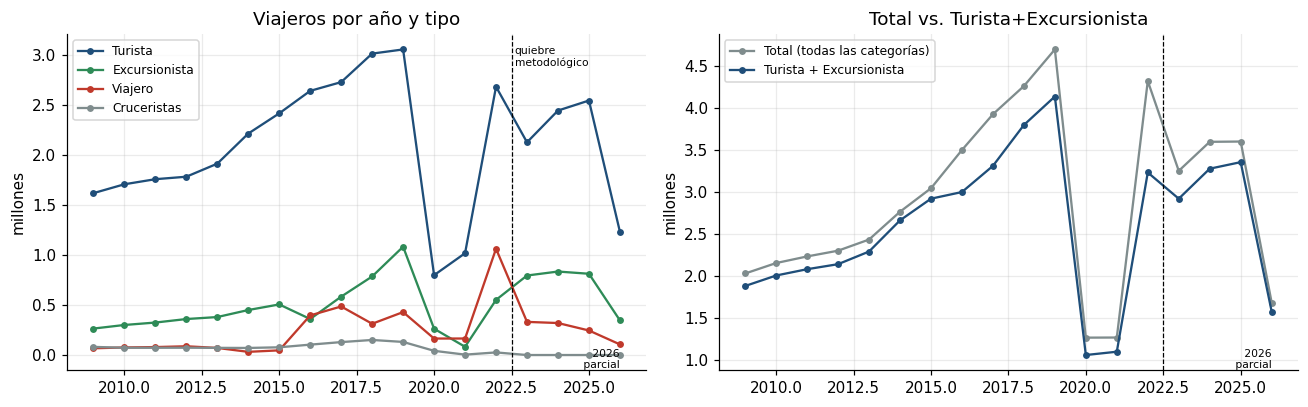

In [9]:
anual = d.pivot_table(index='Año', columns='Tipo de Viajero', values='Viajero',
                      aggfunc='sum', fill_value=0)
anual['TOTAL'] = anual.sum(axis=1)
anual['TUR+EXC'] = anual['Turista'] + anual['Excursionista']
print((anual / 1e6).round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for col, color in [('Turista', AZUL), ('Excursionista', VERDE), ('Viajero', ROJO), ('Cruceristas', GRIS)]:
    ax[0].plot(anual.index, anual[col] / 1e6, marker='o', ms=3.5, label=col, color=color)
ax[0].set(title='Viajeros por año y tipo', ylabel='millones', xlabel='')
ax[0].legend(fontsize=8); ax[0].axvline(2022.5, ls='--', c='k', lw=.8)
ax[0].text(2022.6, ax[0].get_ylim()[1]*.9, 'quiebre\nmetodológico', fontsize=7)

ax[1].plot(anual.index, anual['TOTAL'] / 1e6, marker='o', ms=3.5, label='Total (todas las categorías)', color=GRIS)
ax[1].plot(anual.index, anual['TUR+EXC'] / 1e6, marker='o', ms=3.5, label='Turista + Excursionista', color=AZUL)
ax[1].set(title='Total vs. Turista+Excursionista', ylabel='millones', xlabel='')
ax[1].legend(fontsize=8); ax[1].axvline(2022.5, ls='--', c='k', lw=.8)
for a in ax:
    a.text(2026, a.get_ylim()[0], ' 2026\n parcial', fontsize=7, va='bottom', ha='right')
plt.tight_layout(); guardar('02_tipos_anual'); plt.show()

**Interpretación.** El quiebre es real y grande: la categoría `Viajero` pasa de ~1.06 M en 2022 a
~0.33 M en 2023 (−69 %) sin ninguna causa económica que lo explique. Arrastra al total agregado,
que aparenta caer 25 % de 2022 a 2023, cuando en realidad `Turista` + `Excursionista` solo se mueve
de 3.23 M a 2.92 M (−10 %), y buena parte de esa diferencia también responde a la depuración
(exclusión de compradores fronterizos frecuentes).

**Decisión metodológica:** la **serie obligatoria** ("total mensual de viajeros internacionales") se
construye como **Turista + Excursionista**, que son las dos categorías consistentes en los 210 meses.
Modelar el total crudo produciría un modelo que confunde un cambio de definición administrativa con
una caída de demanda turística, y todo pronóstico heredaría ese sesgo.

También se observa que `Cruceristas` desaparece por completo desde 2023 (deja de medirse en esta
fuente), otra razón para no incluirlo en la serie principal.

### 3.2 La serie mensual total

In [10]:
CONSISTENTES = ['Turista', 'Excursionista']
base = d[d['Tipo de Viajero'].isin(CONSISTENTES)]

serie_total = base.groupby('fecha')['Viajero'].sum().asfreq('MS')
serie_cruda = d.groupby('fecha')['Viajero'].sum().asfreq('MS')

print('Inicio      :', serie_total.index.min().date())
print('Fin         :', serie_total.index.max().date())
print('Frecuencia  : mensual (12 observaciones por año)')
print('Observaciones:', len(serie_total))
print()
print(serie_total.describe().round(0).to_string())

Inicio      : 2009-01-01
Fin         : 2026-06-01
Frecuencia  : mensual (12 observaciones por año)
Observaciones: 210

count       210.0
mean     222438.0
std       84725.0
min        9779.0
25%      170714.0
50%      227606.0
75%      278341.0
max      449114.0


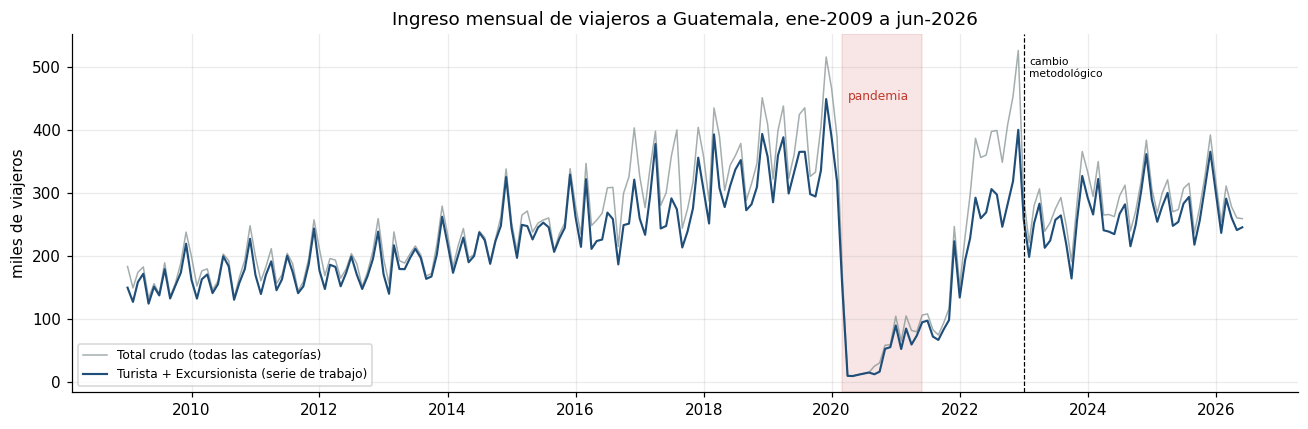

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie_cruda.index, serie_cruda.values, lw=1, color=GRIS, alpha=.7, label='Total crudo (todas las categorías)')
ax.plot(serie_total.index, serie_total.values, lw=1.4, color=AZUL, label='Turista + Excursionista (serie de trabajo)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), color=ROJO, alpha=.12)
ax.text(pd.Timestamp('2020-04-01'), serie_cruda.max()*.85, 'pandemia', fontsize=8, color=ROJO)
ax.axvline(pd.Timestamp('2023-01-01'), ls='--', c='k', lw=.8)
ax.text(pd.Timestamp('2023-02-01'), serie_cruda.max()*.92, 'cambio\nmetodológico', fontsize=7)
ax.set(title='Ingreso mensual de viajeros a Guatemala, ene-2009 a jun-2026',
       ylabel='miles de viajeros', xlabel='')
miles(ax); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); guardar('03_serie_total'); plt.show()

**Qué se ve a primera vista:**

- **Tendencia creciente y sostenida 2009–2019**, de ~1.88 M a ~4.13 M de visitantes anuales
  (+120 % en once años, ~7.4 % anual compuesto).
- **Estacionalidad marcada y estable**, con picos regulares que se repiten cada 12 meses.
- **Un choque abrupto en marzo–abril 2020**: no es un outlier aislado sino un cambio de nivel
  prolongado que dura unos 15 meses.
- **Recuperación en forma de escalón desde mediados de 2021**, que se estabiliza en un nivel
  inferior al de 2019.
- La amplitud de las oscilaciones **crece con el nivel** de la serie: primer indicio de
  varianza no constante, lo que anticipa la necesidad de una transformación logarítmica antes
  de modelar (esto se formaliza en el punto 4 del laboratorio).

### 3.3 El segundo quiebre: los residentes de Guatemala

In [12]:
gt = base[base['País'] == 'Guatemala'].groupby('Año')['Viajero'].sum()
print('Viajeros con residencia en Guatemala, por año (miles):')
print((gt / 1000).round(0).to_string())
print('\nÚltimo año con registros:', gt.index.max())

comp = (base[base['Año'].isin([2022, 2023])]
        .pivot_table(index='País', columns='Año', values='Viajero', aggfunc='sum', fill_value=0)
        .sort_values(2022, ascending=False).head(6) / 1000)
comp['dif'] = comp[2023] - comp[2022]
print('\nComposición 2022 vs 2023 por país (miles):')
print(comp.round(0).to_string())

Viajeros con residencia en Guatemala, por año (miles):
Año
2009     651.0
2010     694.0
2011     718.0
2012     721.0
2013     846.0
2014     992.0
2015    1130.0
2016    1195.0
2017    1323.0
2018    1538.0
2019    1703.0
2020     508.0
2021     437.0
2022    1415.0

Último año con registros: 2022

Composición 2022 vs 2023 por país (miles):
Año                          2022    2023     dif
País                                             
Guatemala                  1415.0     0.0 -1415.0
El Salvador                 728.0  1363.0   634.0
Estados Unidos de América   446.0   566.0   120.0
Honduras                    155.0   325.0   170.0
México                       63.0    83.0    20.0
Costa Rica                   48.0    78.0    30.0


**Interpretación.** Este quiebre no está documentado en las notas del archivo y solo aparece al
mirar los datos: **`Guatemala` figura como país de residencia hasta 2022 y desaparece por completo
desde 2023**. No es un país emisor extranjero: son **guatemaltecos residentes que retornan**. Aportaban
~1.4 millones de personas al año, cerca de un tercio del total, y en 2023 la nueva metodología deja
de contabilizarlos como visitantes.

Ese solo cambio explica buena parte de la caída aparente de 2022 a 2023 y también la de la vía aérea
(La Aurora pasa de 1.39 M a 0.99 M), donde se concentraba ese flujo.

**Consecuencia para el laboratorio:** ninguna serie que dependa de la variable `País` es
perfectamente continua en 2023. Es un argumento fuerte para elegir categorías definidas por
**estructura física** (frontera, vía) antes que por atribución de residencia, y para declarar el
quiebre en cualquier serie que se modele.

### 3.4 Impacto y recuperación de la pandemia

In [13]:
anual_te = serie_total.groupby(serie_total.index.year).sum()
recuperacion = (anual_te / anual_te.loc[2019] * 100).round(1)
print('Visitantes anuales como % del nivel de 2019:')
print(recuperacion.to_string())
print('\n(2026 solo cubre enero-junio)')
sem26 = serie_total['2026-01':'2026-06'].sum()
sem25 = serie_total['2025-01':'2025-06'].sum()
print(f'1er semestre 2026 vs 1er semestre 2025: {sem26/sem25*100:.1f}%')

peor = serie_total.loc['2020-01':'2021-12']
print('\nMes más bajo de toda la serie:', peor.idxmin().date(), f'-> {peor.min():,.0f} viajeros')
print('Abril 2020 vs abril 2019:',
      f"{serie_total['2020-04'].iloc[0]:,.0f} vs {serie_total['2019-04'].iloc[0]:,.0f}",
      f"({100*(1 - serie_total['2020-04'].iloc[0]/serie_total['2019-04'].iloc[0]):.1f}% de caída)")

# ¿Quién entró durante el cierre de fronteras?
cierre = base[(base['fecha'] >= '2020-04-01') & (base['fecha'] <= '2020-08-01')]
print('\nComposición por país durante el cierre (abr-ago 2020):')
print(cierre.groupby('País')['Viajero'].sum().round(0).to_string())

Visitantes anuales como % del nivel de 2019:
fecha
2009     45.5
2010     48.5
2011     50.3
2012     51.8
2013     55.4
2014     64.4
2015     70.6
2016     72.5
2017     80.0
2018     91.8
2019    100.0
2020     25.6
2021     26.6
2022     78.1
2023     70.6
2024     79.2
2025     81.1
2026     38.2

(2026 solo cubre enero-junio)
1er semestre 2026 vs 1er semestre 2025: 97.0%

Mes más bajo de toda la serie: 2020-05-01 -> 9,779 viajeros
Abril 2020 vs abril 2019: 10,039 vs 388,539 (97.4% de caída)

Composición por país durante el cierre (abr-ago 2020):
País
Guatemala    60476.0


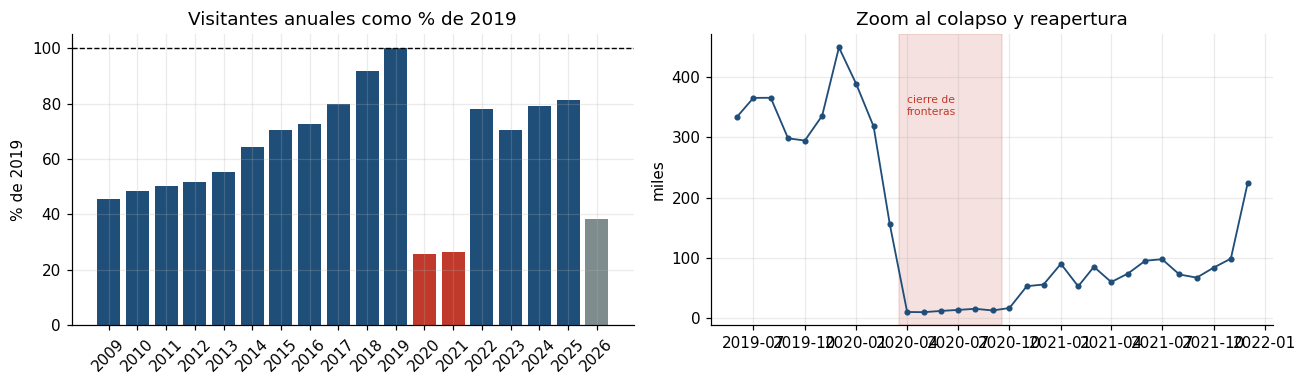

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
colores = [ROJO if a in (2020, 2021) else (GRIS if a == 2026 else AZUL) for a in recuperacion.index]
ax[0].bar(recuperacion.index.astype(str), recuperacion.values, color=colores)
ax[0].axhline(100, ls='--', c='k', lw=.9)
ax[0].set(title='Visitantes anuales como % de 2019', ylabel='% de 2019', xlabel='')
ax[0].tick_params(axis='x', rotation=45)

zoom = serie_total.loc['2019-06':'2021-12']
ax[1].plot(zoom.index, zoom.values, marker='o', ms=3, lw=1.2, color=AZUL)
ax[1].axvspan(pd.Timestamp('2020-03-17'), pd.Timestamp('2020-09-18'), color=ROJO, alpha=.15)
ax[1].text(pd.Timestamp('2020-04-01'), zoom.max()*.75, 'cierre de\nfronteras', fontsize=7, color=ROJO)
ax[1].set(title='Zoom al colapso y reapertura', ylabel='miles'); miles(ax[1])
plt.tight_layout(); guardar('04_recuperacion'); plt.show()

**Interpretación.** Abril y mayo de 2020 son el fondo absoluto de la serie: **97 % menos**
visitantes que el mismo mes del año anterior (~10 mil frente a ~389 mil). 2020 y 2021 cierran ambos
en torno al **26 % del nivel de 2019**.

Un hallazgo que solo aparece al desagregar: **entre abril y agosto de 2020, el 100 % de los ingresos
registrados corresponde a residentes de Guatemala.** El ingreso de extranjeros fue literalmente cero
durante el cierre de fronteras. Es decir, ese piso de ~10-15 mil mensuales no es "turismo residual",
es repatriación.

La recuperación es rápida pero **incompleta**: 2022 llega al 78 % y 2025 —seis años después— se queda
en **81 %**. El primer semestre de 2026 va **3 % por debajo** del mismo semestre de 2025, así que la
brecha no se está cerrando por sí sola.

Consecuencia directa para el modelado: la serie **no** regresa a su trayectoria previa. Un modelo que
extrapole la tendencia 2009–2019 sobrestimará sistemáticamente. Hay un **cambio de nivel permanente**
que el modelo tiene que absorber.

## 4. Países, regiones, vías y fronteras (incisos 1.b, 1.c, 1.d)

Todos los rankings se calculan sobre el **total acumulado del período completo**, como pide la nota
del enunciado, y sobre las categorías consistentes (Turista + Excursionista).

### 4.1 Países de residencia (inciso 1.b)

                             viajeros  % del total
País                                              
El Salvador                14079136.0        30.14
Guatemala                  13870391.0        29.69
Estados Unidos de América   6965680.0        14.91
Honduras                    2520974.0         5.40
México                      1678423.0         3.59
Belice                       916101.0         1.96
Costa Rica                   860241.0         1.84
Nicaragua                    811145.0         1.74
Colombia                     549495.0         1.18
Canadá                       516708.0         1.11
España                       388572.0         0.83
Francia                      329200.0         0.70

Concentración del Top 3: 74.7%

Cobertura temporal de los principales mercados:
  El Salvador                      2009-01 a 2026-06  (205 meses)
  Guatemala                        2009-01 a 2022-12  (168 meses)
  Estados Unidos de América        2009-01 a 2026-06  (205 meses)
  Hondu

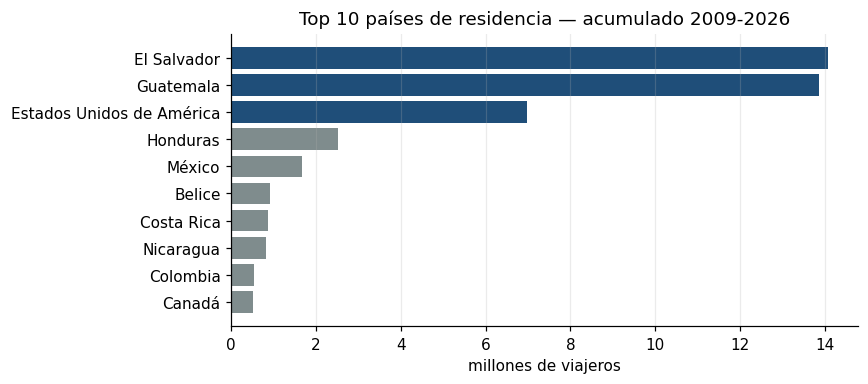

In [15]:
top_paises = base.groupby('País')['Viajero'].sum().sort_values(ascending=False)
tabla = pd.DataFrame({'viajeros': top_paises, '% del total': top_paises / top_paises.sum() * 100})
print(tabla.head(12).round({'viajeros': 0, '% del total': 2}).to_string())
print('\nConcentración del Top 3:', f'{tabla["% del total"].head(3).sum():.1f}%')

# Cobertura temporal de cada mercado: ¿la serie existe en todo el rango?
print('\nCobertura temporal de los principales mercados:')
for p in top_paises.head(6).index:
    sp = base[base['País'] == p].groupby('fecha')['Viajero'].sum()
    print(f'  {p:<32} {sp.index.min().strftime("%Y-%m")} a {sp.index.max().strftime("%Y-%m")}  ({len(sp)} meses)')

fig, ax = plt.subplots(figsize=(8, 3.6))
t10 = top_paises.head(10).sort_values()
ax.barh(t10.index, t10.values / 1e6, color=[AZUL if i >= 7 else GRIS for i in range(len(t10))])
ax.set(title='Top 10 países de residencia — acumulado 2009-2026', xlabel='millones de viajeros')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); guardar('05_paises'); plt.show()

**Interpretación.**

- **El Salvador (14.1 M, 30.1 %)**, **Guatemala (13.9 M, 29.7 %)** y **Estados Unidos (7.0 M, 14.9 %)**
  concentran el **74.7 %** del flujo. La cola es larguísima: más de 200 países aportan el 25 % restante.
  El ranking es el mismo si se mide sobre la medida completa sin filtrar por tipo de viajero
  (El Salvador 16.21 M, Guatemala 14.79 M, Estados Unidos 7.05 M), de modo que **el Top 3 no depende
  de la definición de la medida**.
- El perfil del crecimiento es **regional y terrestre**, no de larga distancia: El Salvador y Honduras
  ganan peso mientras la cuota de Estados Unidos se contrae.
- **Advertencia sobre Guatemala.** Como se vio en la sección 3.3, `Guatemala` deja de registrarse como
  país de residencia desde 2023, así que su serie termina en diciembre de 2022. Entra al Top 3 por
  volumen acumulado y por eso se conserva, pero **sus métricas de error y su cifra de recuperación no
  serán interpretables**: miden el quiebre administrativo, no la demanda. El primer país con serie
  continua fuera del Top 3 sería **Honduras (2.5 M, 5.4 %)**.
- **Limitación adicional:** desde 2023 `País` deja de ser país individual y pasa a ser agrupación de
  mercado (26 grupos en lugar de ~200). Los mercados grandes siguen siendo comparables; los países
  pequeños quedan absorbidos dentro de "Otros Países de Europa", "Resto del Mundo", etc.

### 4.2 Regiones geográficas (inciso 1.c)

                                viajeros      %
Región dos                                     
América Del Centro           33283931.98  71.25
América Del Norte             9160810.15  19.61
Europa                        2149271.06   4.60
América Del Sur y el Caribe   1413590.32   3.03
Asia                           410333.51   0.88
Oceanía                        135505.37   0.29
Oriente Medio                  133735.19   0.29
Otros Paises Del Mundo          23914.30   0.05
Sin especificar                   821.00   0.00

Concentración del Top 3: 95.5%


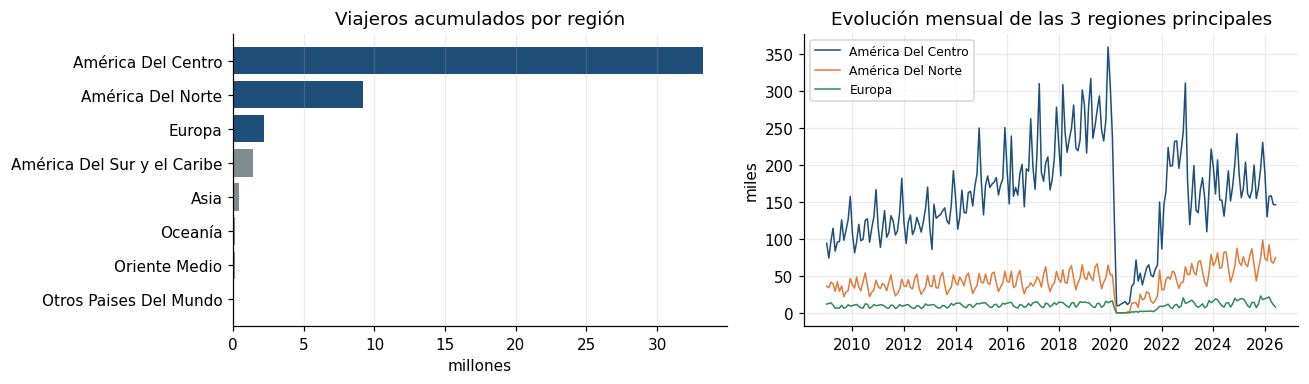

In [16]:
reg = base.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)
print(pd.DataFrame({'viajeros': reg, '%': reg / reg.sum() * 100}).round(2).to_string())
print('\nConcentración del Top 3:', f'{(reg.head(3).sum()/reg.sum()*100):.1f}%')

top3_reg = list(reg.head(3).index)
evol = (base[base['Región dos'].isin(top3_reg)]
        .pivot_table(index='fecha', columns='Región dos', values='Viajero', aggfunc='sum')
        .asfreq('MS').fillna(0))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
r8 = reg.head(8).sort_values()
ax[0].barh(r8.index, r8.values / 1e6, color=[AZUL if i >= 5 else GRIS for i in range(len(r8))])
ax[0].set(title='Viajeros acumulados por región', xlabel='millones'); ax[0].grid(axis='y', alpha=0)
for col, color in zip(top3_reg, [AZUL, NARANJA, VERDE]):
    ax[1].plot(evol.index, evol[col], lw=1, label=col, color=color)
ax[1].set(title='Evolución mensual de las 3 regiones principales', ylabel='miles'); miles(ax[1])
ax[1].legend(fontsize=8)
plt.tight_layout(); guardar('06_regiones'); plt.show()

**Interpretación.** **América Central (33.3 M, 71.3 %)**, **América del Norte (9.2 M, 19.6 %)** y
**Europa (2.1 M, 4.6 %)** dominan: juntas explican el **95.5 %** del flujo.

Los tres perfiles son muy distintos, y por eso vale la pena modelarlos por separado en lugar de
confiar solo en el agregado:

| | América Central | América del Norte | Europa |
|---|---|---|---|
| Vía predominante | terrestre | aérea | aérea |
| Volumen | muy alto | medio | bajo |
| Estacionalidad | marcada (dic, Semana Santa) | moderada | temporada larga (jun–ago) |
| Recuperación post-COVID | rápida | media | la más lenta |

Un modelo único sobre el total promedia tres dinámicas que no comparten ni el patrón estacional ni la
velocidad de recuperación. Nota: América Central absorbe la mayor parte del quiebre de 2023, porque
los residentes de Guatemala estaban clasificados en esa región.

### 4.3 Vías de ingreso (inciso 1.d, parte 1)

In [17]:
via_te = base.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
via_crudo = d.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
print('Sobre Turista+Excursionista:')
print(pd.DataFrame({'viajeros': via_te, '%': via_te / via_te.sum() * 100}).round(2).to_string())
print('\nSobre todas las categorías (incluye Cruceristas y Viajero):')
print(pd.DataFrame({'viajeros': via_crudo, '%': via_crudo / via_crudo.sum() * 100}).round(2).to_string())

via_anual = base.pivot_table(index='Año', columns='Vía', values='Viajero', aggfunc='sum', fill_value=0)
print('\nTurista+Excursionista por vía y año (miles):')
print((via_anual / 1000).round(0).to_string())

Sobre Turista+Excursionista:
              viajeros      %
Vía                          
Terrestre  27592253.33  59.07
Aérea      19019418.55  40.72
Marítima     100241.00   0.21

Sobre todas las categorías (incluye Cruceristas y Viajero):
              viajeros      %
Vía                          
Terrestre  31995304.91  61.19
Aérea      19063850.19  36.46
Marítima    1228782.00   2.35

Turista+Excursionista por vía y año (miles):
Vía    Aérea  Marítima  Terrestre
Año                              
2009   935.0      12.0      932.0
2010   974.0      13.0     1018.0
2011   956.0      13.0     1111.0
2012   971.0      13.0     1156.0
2013   997.0      13.0     1280.0
2014  1092.0      13.0     1555.0
2015  1167.0      12.0     1739.0
2016  1255.0      11.0     1731.0
2017  1314.0       0.0     1994.0
2018  1415.0       0.0     2379.0
2019  1483.0       0.0     2649.0
2020   404.0       0.0      656.0
2021   703.0       0.0      395.0
2022  1390.0       0.0     1839.0
2023   986.0       0

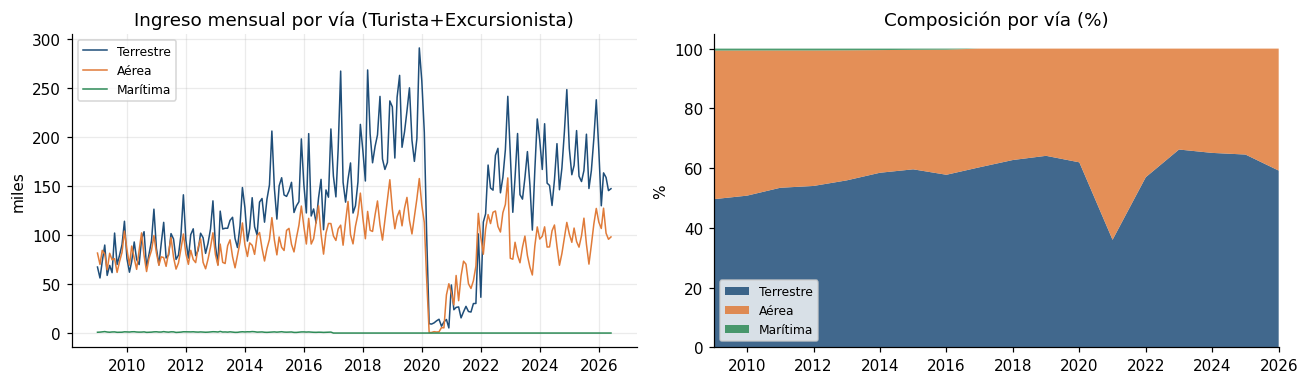

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
via_m = base.pivot_table(index='fecha', columns='Vía', values='Viajero', aggfunc='sum').asfreq('MS').fillna(0)
for col, color in zip(['Terrestre', 'Aérea', 'Marítima'], [AZUL, NARANJA, VERDE]):
    ax[0].plot(via_m.index, via_m[col], lw=1, label=col, color=color)
ax[0].set(title='Ingreso mensual por vía (Turista+Excursionista)', ylabel='miles'); miles(ax[0])
ax[0].legend(fontsize=8)

share = via_anual.div(via_anual.sum(axis=1), axis=0) * 100
ax[1].stackplot(share.index, share['Terrestre'], share['Aérea'], share['Marítima'],
                labels=['Terrestre', 'Aérea', 'Marítima'], colors=[AZUL, NARANJA, VERDE], alpha=.85)
ax[1].set(title='Composición por vía (%)', ylabel='%', xlim=(2009, 2026))
ax[1].legend(fontsize=8, loc='lower left'); ax[1].grid(alpha=0)
plt.tight_layout(); guardar('07_vias'); plt.show()

**Interpretación.** Medido sobre visitantes (Turista + Excursionista), la vía **terrestre domina con
59.1 %**, seguida de la **aérea (40.7 %)** y una **marítima residual (0.2 %)**. Si se mide sobre todas
las categorías, la marítima sube a **2.4 %** porque casi todo su volumen histórico son **cruceristas**
(el 89.5 % de la vía).

La composición no es estática: la terrestre gana peso de forma sostenida hasta 2019, salvo en 2021,
cuando la aérea la supera (703 mil frente a 395 mil) porque los cierres fronterizos terrestres duraron
más que la reapertura del aeropuerto. Es un buen ejemplo de que la pandemia **no afectó a todas las
series por igual**.

**La vía marítima y la definición de la medida.** Bajo el filtro `Turista + Excursionista` la serie
marítima queda **en cero desde 2017**: a partir de ese año prácticamente todo el ingreso marítimo se
registra como `Cruceristas`, que el filtro excluye. Como el enunciado pide construir una serie mensual
**para cada una de las tres vías**, aplicar ese filtro dejaría a una de ellas sin nada que analizar.

Por eso, cuando se modelan las vías (cuaderno 03) se trabaja con la **medida completa, sin filtrar por
tipo de viajero**, y bajo esa definición la serie marítima **sí existe en los 210 meses**. Sigue siendo
la más difícil del conjunto —27 meses en cero, un colapso en 2020 del que no se recupera y la pérdida
de la categoría `Cruceristas` desde 2023—, y así se reporta.

### 4.4 Fronteras de ingreso (inciso 1.d, parte 2)

                                 viajeros      %
Frontera                                        
01 La Aurora                   18989985.0  40.65
07 Valle Nuevo                 10143045.0  21.71
09 San Cristóbal                4183632.0   8.96
08 Pedro de Alvarado            3764229.0   8.06
10 La Ermita (Nueva Anguiatú)   2587072.0   5.54
20 Melchor de Mencos            1782864.0   3.82
13 El Cinchado / El Corinto     1213485.0   2.60
11 Agua Caliente                 922420.0   1.97
12 El Florido                    910373.0   1.95
15 El Carmen                     852663.0   1.83

Concentración del Top 3: 71.3%
Concentración del Top 6: 88.7%

Cruce Frontera x Vía (millones):
Vía                            Aérea  Marítima  Terrestre
Frontera                                                 
01 La Aurora                   18.99       0.0       0.00
07 Valle Nuevo                  0.00       0.0      10.14
09 San Cristóbal                0.00       0.0       4.18
08 Pedro de Alvarado     

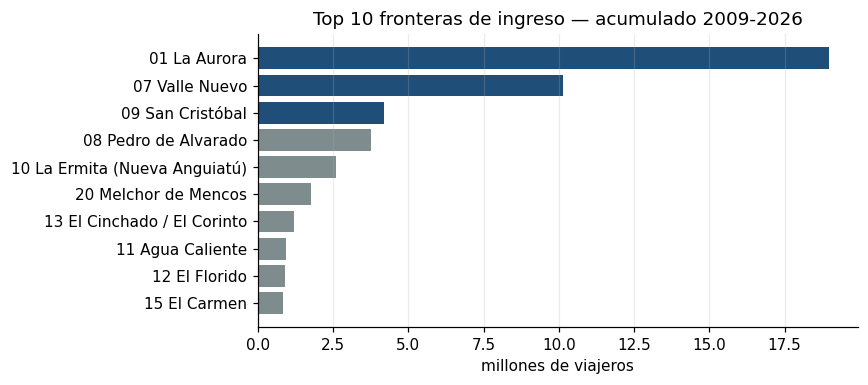

In [19]:
fr = base.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False)
tabla_fr = pd.DataFrame({'viajeros': fr, '%': fr / fr.sum() * 100})
print(tabla_fr.head(10).round({'viajeros': 0, '%': 2}).to_string())
print('\nConcentración del Top 3:', f'{tabla_fr["%"].head(3).sum():.1f}%')
print('Concentración del Top 6:', f'{tabla_fr["%"].head(6).sum():.1f}%')

cruce = (base.pivot_table(index='Frontera', columns='Vía', values='Viajero', aggfunc='sum', fill_value=0)
         .loc[fr.head(6).index] / 1e6)
print('\nCruce Frontera x Vía (millones):')
print(cruce.round(2).to_string())

print('\nContinuidad anual de las 3 principales (miles):')
print((base[base['Frontera'].isin(fr.head(3).index)]
       .pivot_table(index='Año', columns='Frontera', values='Viajero', aggfunc='sum') / 1000).round(0).to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))
f10 = fr.head(10).sort_values()
ax.barh(f10.index, f10.values / 1e6, color=[AZUL if i >= 7 else GRIS for i in range(len(f10))])
ax.set(title='Top 10 fronteras de ingreso — acumulado 2009-2026', xlabel='millones de viajeros')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); guardar('08_fronteras'); plt.show()

**Interpretación.** El flujo está **muy concentrado**: **La Aurora (19.0 M, 40.7 %)**,
**Valle Nuevo (10.1 M, 21.7 %)** y **San Cristóbal (4.2 M, 9.0 %)** absorben el **71.3 %** de los
ingresos; las seis primeras llegan al **88.7 %**.

El cruce frontera × vía confirma la lectura estructural: La Aurora **es** el flujo aéreo (el 100 % de
su volumen), y las cinco fronteras que le siguen son terrestres, todas sobre la línea con **El Salvador
y Honduras** — coherente con que El Salvador sea el primer mercado emisor.

Las tres principales tienen serie **completa y continua en los 210 meses**, sin el problema de
granularidad que afecta a `País`. La Aurora sí registra el escalón de 2023 (1.39 M → 0.99 M) por la
salida de los residentes guatemaltecos, pero es un quiebre identificable y explicable, no una pérdida
de la serie.

**Implicación para el INGUAT:** un plan de capacidad, señalización o promoción concentrado en tres
puestos cubre casi tres cuartas partes del flujo total del país.

## 5. Estacionalidad y estadísticas descriptivas (inciso 1.f)

El patrón intra-anual se analiza sobre el período **pre-pandemia (2009–2019)**, para que el colapso de
2020–2021 no distorsione el perfil estacional.

Índice estacional (promedio del año = 100):
Ene     98.4
Feb     81.2
Mar    107.8
Abr    105.7
May     87.6
Jun     95.5
Jul    107.4
Ago    104.4
Sep     82.7
Oct     92.0
Nov    103.5
Dic    133.8

Amplitud (máx - mín): 52.6 puntos


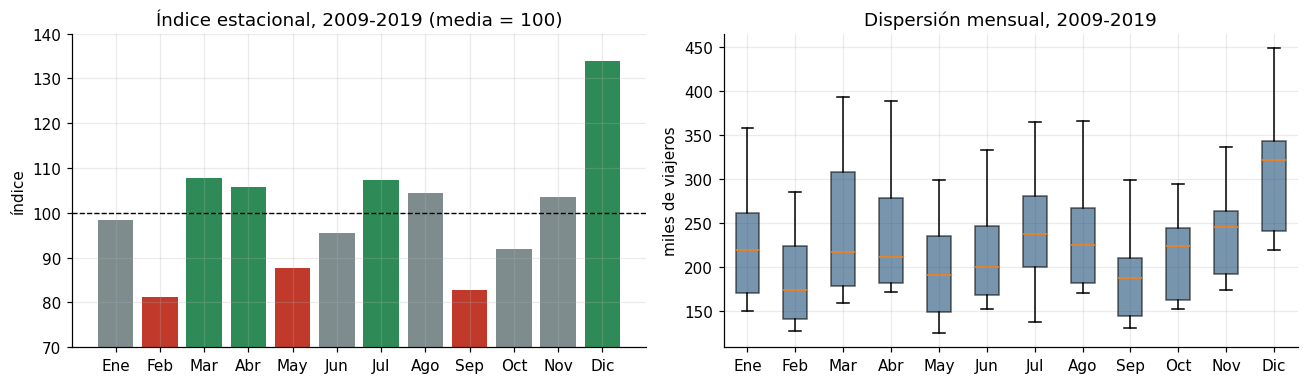

In [20]:
pre = serie_total.loc[:'2019-12']
indice = (pre.groupby(pre.index.month).mean() / pre.mean() * 100).round(1)
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
indice.index = meses
print('Índice estacional (promedio del año = 100):')
print(indice.to_string())
print('\nAmplitud (máx - mín):', round(indice.max() - indice.min(), 1), 'puntos')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
colores = [ROJO if x < 90 else (VERDE if x > 105 else GRIS) for x in indice.values]
ax[0].bar(indice.index, indice.values, color=colores)
ax[0].axhline(100, ls='--', c='k', lw=.9)
ax[0].set(title='Índice estacional, 2009-2019 (media = 100)', ylabel='índice', ylim=(70, 140))

datos_box = [pre[pre.index.month == m].values / 1000 for m in range(1, 13)]
bp = ax[1].boxplot(datos_box, labels=meses, patch_artist=True)
for p in bp['boxes']:
    p.set_facecolor(AZUL); p.set_alpha(.6)
ax[1].set(title='Dispersión mensual, 2009-2019', ylabel='miles de viajeros')
plt.tight_layout(); guardar('09_estacionalidad'); plt.show()

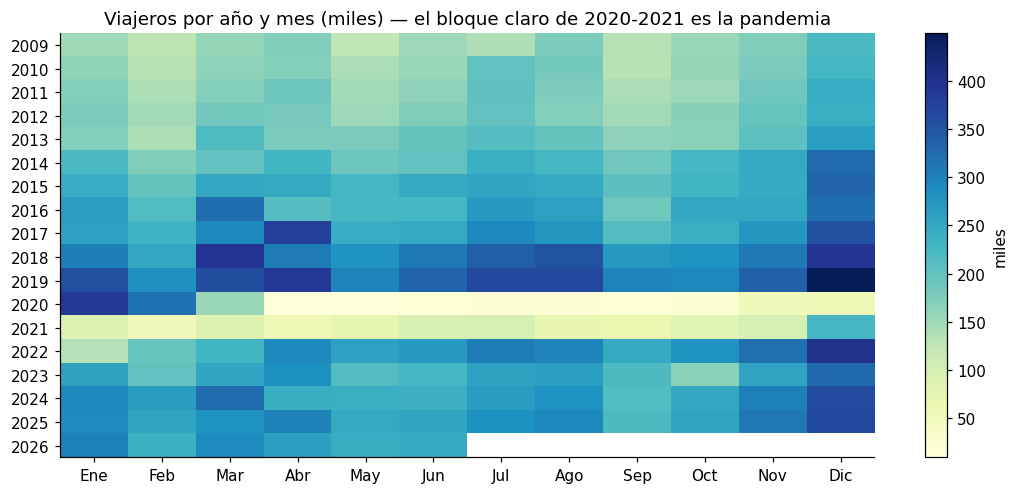

In [21]:
piv = (serie_total.to_frame('v')
       .assign(anio=serie_total.index.year, mes=serie_total.index.month)
       .pivot_table(index='anio', columns='mes', values='v') / 1000)

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(piv.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(12), meses); ax.set_yticks(range(len(piv)), piv.index)
ax.set(title='Viajeros por año y mes (miles) — el bloque claro de 2020-2021 es la pandemia')
plt.colorbar(im, ax=ax, label='miles'); ax.grid(alpha=0)
plt.tight_layout(); guardar('10_heatmap'); plt.show()

**Interpretación.** El patrón estacional es nítido y **muy estable año con año**:

- **Diciembre es el máximo absoluto (índice 134)** — fiestas de fin de año y visita de la diáspora.
- **Marzo–abril (108 / 106)** — Semana Santa. Es una **fiesta móvil**, así que en algunos años el pico
  cae en marzo y en otros en abril. Eso introduce ruido que un modelo estacional de período fijo (12)
  no captura del todo; conviene mencionarlo al analizar residuos.
- **Julio–agosto (107 / 104)** — vacaciones de mitad de año.
- **Los mínimos son febrero (81) y septiembre (83)**, ambos ~20 % por debajo del promedio.

La amplitud entre el mejor y el peor mes es de **52.6 puntos**: la componente estacional es
económicamente relevante, no un detalle estadístico. El mapa de calor muestra además que el patrón
se conserva en el período post-pandemia, solo que a menor nivel: **la estacionalidad sobrevivió al
choque; el nivel no.**

### 5.1 Estadísticas descriptivas de las series candidatas

In [22]:
def serie_de(filtro):
    return base[filtro].groupby('fecha')['Viajero'].sum().reindex(
        pd.date_range('2009-01-01', '2026-06-01', freq='MS')).fillna(0)

candidatas = {
    'Total (Tur+Exc)':      serie_total,
    'País: El Salvador':    serie_de(base['País'] == 'El Salvador'),
    'País: Estados Unidos': serie_de(base['País'] == 'Estados Unidos de América'),
    'País: Honduras':       serie_de(base['País'] == 'Honduras'),
    'País: Guatemala':      serie_de(base['País'] == 'Guatemala'),
    'Reg: América Central': serie_de(base['Región dos'] == 'América Del Centro'),
    'Reg: América Norte':   serie_de(base['Región dos'] == 'América Del Norte'),
    'Reg: Europa':          serie_de(base['Región dos'] == 'Europa'),
    'Fr: La Aurora':        serie_de(base['Frontera'] == '01 La Aurora'),
    'Fr: Valle Nuevo':      serie_de(base['Frontera'] == '07 Valle Nuevo'),
    'Fr: San Cristóbal':    serie_de(base['Frontera'] == '09 San Cristóbal'),
    'Vía: Marítima':        serie_de(base['Vía'] == 'Marítima'),
}

resumen = pd.DataFrame({
    'inicio':      [s.index.min().strftime('%Y-%m') for s in candidatas.values()],
    'fin':         [s.index.max().strftime('%Y-%m') for s in candidatas.values()],
    'meses_con_0': [int((s == 0).sum()) for s in candidatas.values()],
    'media':       [s.mean() for s in candidatas.values()],
    'mediana':     [s.median() for s in candidatas.values()],
    'desv_est':    [s.std() for s in candidatas.values()],
    'CV_%':        [s.std() / s.mean() * 100 for s in candidatas.values()],
    'min':         [s.min() for s in candidatas.values()],
    'max':         [s.max() for s in candidatas.values()],
    'asimetria':   [s.skew() for s in candidatas.values()],
}, index=candidatas.keys())
print(resumen.round(1).to_string())

                       inicio      fin  meses_con_0     media   mediana  desv_est   CV_%     min       max  asimetria
Total (Tur+Exc)       2009-01  2026-06            0  222437.7  227605.7   84724.9   38.1  9779.0  449114.1       -0.3
País: El Salvador     2009-01  2026-06            5   67043.5   58703.5   39195.5   58.5     0.0  190579.0        0.6
País: Estados Unidos  2009-01  2026-06            5   33169.9   30041.8   15355.4   46.3     0.0   78927.2        0.5
País: Honduras        2009-01  2026-06            5   12004.6    8975.2    8074.1   67.3     0.0   35252.5        1.2
País: Guatemala       2009-01  2026-06           42   66049.5   65159.2   47800.0   72.4     0.0  198429.0        0.2
Reg: América Central  2009-01  2026-06            0  158494.9  157371.6   66477.1   41.9  9779.0  359173.0        0.2
Reg: América Norte    2009-01  2026-06            5   43622.9   41458.8   17881.1   41.0     0.0   98379.8        0.1
Reg: Europa           2009-01  2026-06            5   10

**Interpretación.** Todas las series comparten inicio (2009-01), fin (2026-06) y frecuencia (mensual,
210 observaciones). Lo que las distingue:

- La columna **`meses_con_0` es la más informativa de la tabla**: es el diagnóstico rápido de si una
  serie es utilizable. `Guatemala` tiene 42 meses en cero (todo 2023–2026) y `Marítima` 114 (todo
  2017–2026). Ambas quedan descartadas por construcción, no por criterio estético.
- Los cinco ceros que comparten El Salvador, Estados Unidos y Honduras son **abril–agosto 2020**: el
  cierre de fronteras, un cero real, no un dato faltante.
- La **volatilidad relativa (CV)** ordena las series: La Aurora (30.7 %) y el total (38.1 %) son las
  más estables; Honduras (67.3 %) y El Salvador (58.5 %) las más volátiles entre las utilizables. El
  CV de Marítima (113 %) no mide volatilidad real sino el hueco de medición.
- La asimetría positiva de casi todas confirma lo visto en el gráfico: **la varianza crece con el
  nivel**, señal de que conviene una **transformación logarítmica** antes de modelar.

## 6. Valores atípicos en la serie (inciso 1.e, parte 2)

Un valor atípico en una serie de tiempo no es un valor extremo del histograma, sino uno que se aparta
de lo que la propia serie predice dadas su tendencia y su estacionalidad. Por eso comparamos dos
criterios.

In [23]:
# Criterio 1: rango intercuartílico sobre los valores crudos
q1, q3 = serie_total.quantile([.25, .75]); iqr = q3 - q1
out_iqr = serie_total[(serie_total < q1 - 1.5*iqr) | (serie_total > q3 + 1.5*iqr)]
print('Outliers por IQR sobre el valor crudo:', len(out_iqr))
print(out_iqr.round(0).to_string() if len(out_iqr) else '(ninguno)')

# Criterio 2: residuos de una descomposición STL robusta sobre el logaritmo
res = STL(np.log(serie_total), period=12, robust=True).fit()
z = (res.resid - res.resid.median()) / res.resid.std()
out_stl = z[abs(z) > 3]
print('\nOutliers por residuo STL (|z| > 3):', len(out_stl))
print(out_stl.round(2).to_string())

Outliers por IQR sobre el valor crudo: 1
fecha
2019-12-01    449114.0
Freq: MS

Outliers por residuo STL (|z| > 3): 7
fecha
2020-04-01   -7.04
2020-05-01   -5.76
2020-06-01   -5.44
2020-07-01   -5.47
2020-08-01   -4.16
2020-09-01   -4.06
2020-10-01   -3.57
Freq: MS


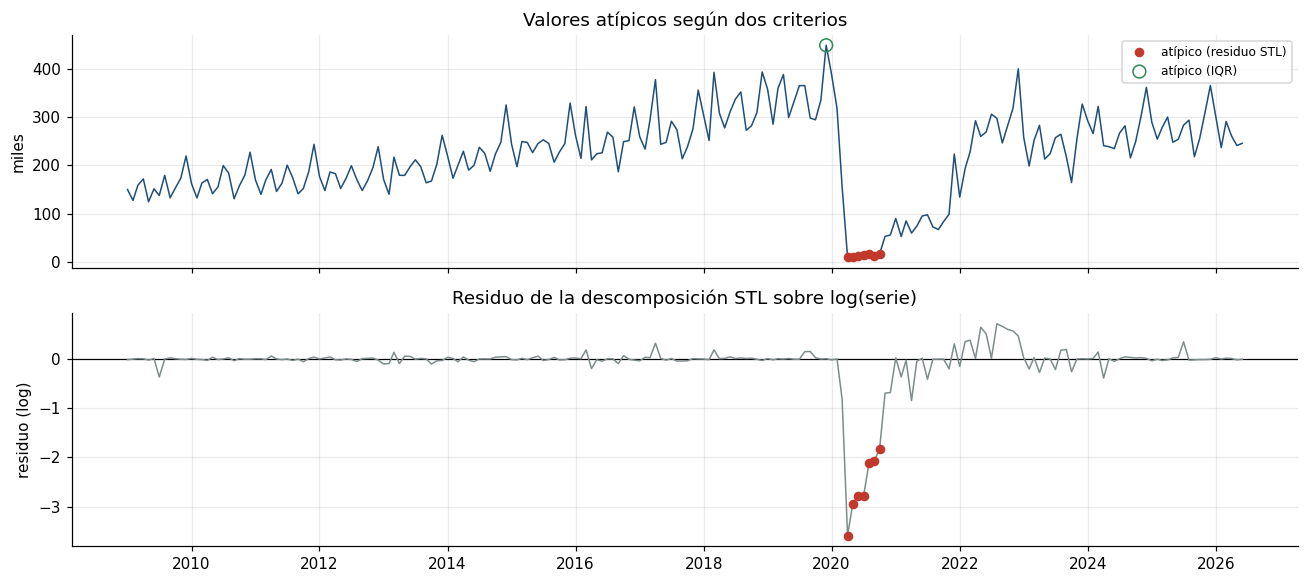

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True)
ax[0].plot(serie_total.index, serie_total.values, lw=1, color=AZUL)
ax[0].scatter(out_stl.index, serie_total.loc[out_stl.index], color=ROJO, zorder=5, s=28,
              label='atípico (residuo STL)')
ax[0].scatter(out_iqr.index, serie_total.loc[out_iqr.index], facecolors='none', edgecolors=VERDE,
              s=70, zorder=5, label='atípico (IQR)')
ax[0].set(title='Valores atípicos según dos criterios', ylabel='miles'); miles(ax[0])
ax[0].legend(fontsize=8)

ax[1].axhline(0, c='k', lw=.8)
ax[1].plot(res.resid.index, res.resid.values, lw=1, color=GRIS)
ax[1].scatter(out_stl.index, res.resid.loc[out_stl.index], color=ROJO, zorder=5, s=28)
ax[1].set(title='Residuo de la descomposición STL sobre log(serie)', ylabel='residuo (log)')
plt.tight_layout(); guardar('11_outliers'); plt.show()

**Interpretación — y por qué importa la diferencia entre los dos criterios.**

El criterio del **IQR sobre el valor crudo detecta un solo punto: diciembre 2019**, el máximo histórico.
Y **no detecta ninguno de los meses de la pandemia**, que son los valores más anómalos de toda la serie.
La razón es que la serie tiene tendencia y estacionalidad fuertes, de modo que su rango intercuartílico
es enorme; los ~10 mil viajeros de abril 2020 caen dentro de ese rango amplísimo aunque sean absurdos
para un mes de abril.

El criterio basado en **residuos STL** —que descuenta primero tendencia y estacionalidad— identifica
correctamente **siete meses consecutivos, de abril a octubre de 2020**, con abril 2020 a 7 desviaciones
estándar de lo esperado.

**Conclusión práctica:** los atípicos de esta serie **no son errores de registro y no deben eliminarse
ni imputarse**. Son un choque exógeno real y agrupado en el tiempo. La forma correcta de tratarlos es
(a) con variables dummy de intervención en un ARIMAX, (b) con estimación robusta, o (c) documentando
que el modelo tendrá residuos grandes en esa ventana. "Limpiarlos" sería borrar el evento más
informativo de la serie.

## 7. Preparación del punto 2: partición 70/30

En series de tiempo el corte debe ser **cronológico**, nunca aleatorio: usar datos del futuro para
predecir el pasado es fuga de información y produce métricas de error optimistas y falsas.

Entrenamiento: 2009-01-01 a 2021-03-01  (147 meses, 70%)
Prueba       : 2021-04-01 a 2026-06-01  (63 meses, 30%)

Media entrenamiento: 214,218   Media prueba: 241,617


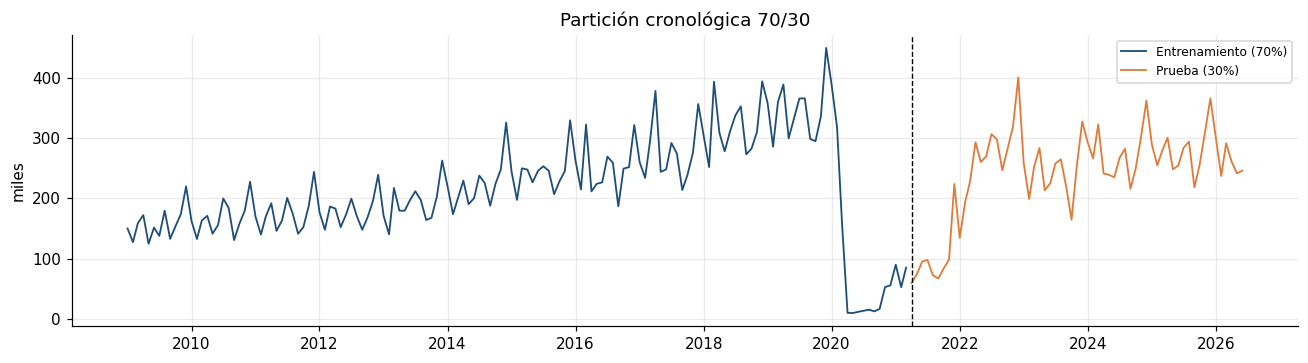

In [25]:
n = len(serie_total)
corte = int(n * 0.70)
train, test = serie_total.iloc[:corte], serie_total.iloc[corte:]

print(f'Entrenamiento: {train.index.min().date()} a {train.index.max().date()}  ({len(train)} meses, {len(train)/n:.0%})')
print(f'Prueba       : {test.index.min().date()} a {test.index.max().date()}  ({len(test)} meses, {len(test)/n:.0%})')
print(f'\nMedia entrenamiento: {train.mean():,.0f}   Media prueba: {test.mean():,.0f}')

fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(train.index, train.values, lw=1.2, color=AZUL, label='Entrenamiento (70%)')
ax.plot(test.index, test.values, lw=1.2, color=NARANJA, label='Prueba (30%)')
ax.axvline(test.index.min(), ls='--', c='k', lw=.9)
ax.set(title='Partición cronológica 70/30', ylabel='miles'); miles(ax); ax.legend(fontsize=8)
plt.tight_layout(); guardar('12_split'); plt.show()

**Advertencia importante para el punto 2.** El corte al 70 % cae en **marzo de 2021**, es decir,
justo dentro del hueco pandémico. El conjunto de entrenamiento termina en el piso del colapso y el de
prueba contiene toda la recuperación.

Es una partición **difícil y honesta**: cualquier modelo entrenado hasta marzo 2021 va a subestimar el
conjunto de prueba, porque no tiene forma de anticipar la reapertura. Hay que ser explícito al reportar
MAE y RMSE — un error alto en el test **no** implica necesariamente que el modelo esté mal
especificado. Vale la pena reportar, además, una partición alternativa sobre el período post-pandemia
como análisis de sensibilidad; por ahora se respeta el 70/30 que pide el enunciado.

## 8. Series que se construirán en el punto 3

El enunciado pide elegir **dos** de las cinco categorías propuestas. La selección es
**Países de residencia** y **Vías de ingreso**, que son las dos de mayor valor directo para el INGUAT:
una responde a *de dónde viene* el visitante (promoción de mercados) y la otra a *cómo entra*
(capacidad e infraestructura).

**Selección:**

- **Serie obligatoria:** total mensual de viajeros internacionales.
- **Categoría i — Países de residencia (Top 3 acumulado):** El Salvador, Guatemala, Estados Unidos.
- **Categoría iii — Vías de ingreso:** Aérea, Terrestre, Marítima.

En total, **7 series mensuales**.

**Definición de la medida.** Estas series se construyen sobre el total de viajeros **sin filtrar por
tipo**. El filtro `Turista + Excursionista` que sugiere el enunciado es el correcto para comparar
volúmenes en todo el rango, pero dejaría la vía **Marítima en cero desde 2017** (sección 4.3) y, por
tanto, sin serie que analizar. El quiebre metodológico de 2023 no se ignora: se documenta y se corrige
explícitamente en toda comparación que cruce ese año.

**Dos series quedan estructuralmente truncadas**, y se declara desde ahora porque condiciona la lectura
de todo el análisis posterior:

| Serie | Problema | Consecuencia |
|---|---|---|
| `Guatemala` | Deja de registrarse en 2023; 42 de los 63 meses de prueba en cero | Métricas de error y recuperación **no interpretables** |
| `Marítima` | 27 meses en cero; colapso de cruceros en 2020 más pérdida de la categoría en 2023 | Resultados **no concluyentes**; se reportan como tales |

Ambas se conservan porque el enunciado obliga: el Top 3 de países por acumulado incluye a Guatemala, y
las tres vías deben construirse todas. La alternativa —sustituirlas por series más cómodas— sería
responder a una pregunta distinta de la que se hizo.

**Nota sobre la construcción.** Las siete series definitivas se construyen y analizan en
`03_Modelado_Prediccion.ipynb`, que las regenera desde el archivo crudo. La celda siguiente las deja
armadas aquí para cerrar el exploratorio.

In [ ]:
# Construcción de las 7 series del punto 3, sobre la medida completa (sin filtrar por tipo).
# Nota: el resto de este cuaderno trabaja sobre `base` (Turista + Excursionista); aquí se parte
# de `d`, la tabla completa, por la razón explicada arriba (la vía Marítima).
IDX = pd.date_range('2009-01-01', '2026-06-01', freq='MS')

def serie_completa(mascara):
    return d[mascara].groupby('fecha')['Viajero'].sum().reindex(IDX).fillna(0)

top3_paises = d.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()

series_finales = {'total': d.groupby('fecha')['Viajero'].sum().reindex(IDX).fillna(0)}
for p in top3_paises:
    series_finales['pais_' + p] = serie_completa(d['País'] == p)
for v in ['Aérea', 'Terrestre', 'Marítima']:
    series_finales['via_' + v] = serie_completa(d['Vía'] == v)

out = pd.DataFrame(series_finales).round(0)
out.to_csv('series_mensuales.csv')

print('Top 3 países (acumulado):', top3_paises)
print('Series construidas:', len(out.columns), '\n')
for c_ in out.columns:
    s_ = out[c_]
    print(f'  {c_:<34} inicio {out.index.min():%Y-%m} | fin {out.index.max():%Y-%m} '
          f'| mensual | n = {len(out)} | meses en 0: {int((s_ == 0).sum())}')

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(13, 10), sharex=True)
for ax, col in zip(axes.ravel(), out.columns):
    ax.plot(out.index, out[col], lw=1, color=AZUL)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    miles(ax)
axes.ravel()[-1].axis('off')
fig.suptitle('Las 7 series mensuales del laboratorio (miles de viajeros)', y=1.0)
plt.tight_layout(); guardar('13_panel_series'); plt.show()

## 9. Hallazgos principales

1. **El total crudo no es modelable.** El quiebre metodológico 2022→2023 hunde la categoría `Viajero`
   un 69 % por reclasificación, no por demanda. Se trabaja con **Turista + Excursionista**.
2. **Segundo quiebre, no documentado:** `Guatemala` como país de residencia (~1.4 M al año, un tercio
   del total) desaparece desde 2023. Explica buena parte de la caída aparente de 2023 y del escalón
   de La Aurora.
3. **Los datos están completos:** 210 meses consecutivos, cero nulos, cero duplicados reales. Los
   problemas de calidad son de *etiquetado* (faltantes escritos como `'0'` y `'0x2a'`, categorías de
   crucero dentro de una variable geográfica) y afectan el 0.05 % del volumen.
4. **Tendencia fuerte 2009–2019** (+120 %, ~7.4 % anual) seguida de un **cambio de nivel permanente**:
   2025 sigue 19 % por debajo de 2019 y el primer semestre de 2026 va 3 % por debajo de 2025.
5. **Estacionalidad marcada y estable**: máximo en diciembre (índice 134), mínimos en febrero (81) y
   septiembre (83), amplitud de 53 puntos. Sobrevive intacta a la pandemia. La Semana Santa, al ser
   móvil, desplaza el pico entre marzo y abril y añadirá ruido a un modelo de período fijo.
6. **La varianza crece con el nivel** → se anticipa la necesidad de transformación logarítmica.
7. **Los atípicos son abril–octubre 2020 y son reales**; se modelan, no se eliminan. El IQR sobre
   valores crudos no los detecta: hace falta un criterio basado en residuos.
8. **Durante el cierre de fronteras (abr–ago 2020) el 100 % de los ingresos fueron residentes
   guatemaltecos**: el ingreso de extranjeros fue exactamente cero.
9. **Alta concentración:** 3 países = 74.7 % del flujo, 3 fronteras = 71.3 %, 3 regiones = 95.5 %.
10. **El corte 70/30 cae en marzo 2021**, dentro del hueco pandémico: hay que advertirlo al interpretar
    MAE y RMSE.